STAGE 1: Loading & labeling
Raw rows: 681,994
After dropping nulls + neutrals: 623,758
Class balance -> Neg: 304,068  Pos: 319,690
Apps: {'Tinder': np.int64(482520), 'Bumble': np.int64(93537), 'Hinge': np.int64(47701)}

STAGE 2: Text preprocessing
Cleaned in 7.8s. Final rows: 617,752

STAGE 3: CountVectorizer (Bag-of-Words)
Vectorized in 9.2s
Feature matrix: (617752, 17073)  (sparse, 4,325,111 non-zeros)

STAGE 4: Chi-square feature selection
Selected top 3000 features in 0.5s
Reduced feature matrix: (617752, 3000)

STAGE 5: 80/20 stratified split
Train: 494,201  Test: 123,551

STAGE 6: Training the three models

Logistic Regression
  Train: 7.9s  |  Acc=0.8974  F1=0.9008  Prec=0.8880  Rec=0.9139

Multinomial Naive Bayes
  Train: 0.1s  |  Acc=0.8867  F1=0.8891  Prec=0.8867  Rec=0.8916

Decision Tree
  Train: 20.6s  |  Acc=0.7773  F1=0.8056  Prec=0.7257  Rec=0.9052

FINAL COMPARISON
                         Accuracy  F1-Score  Precision  Recall  Train time (s)
Logistic Regression       

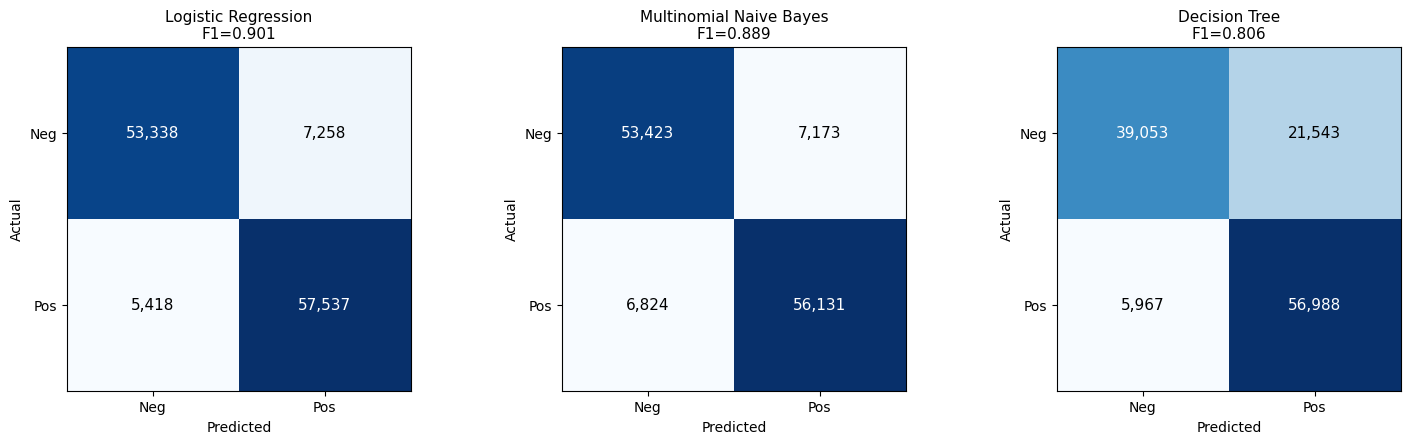

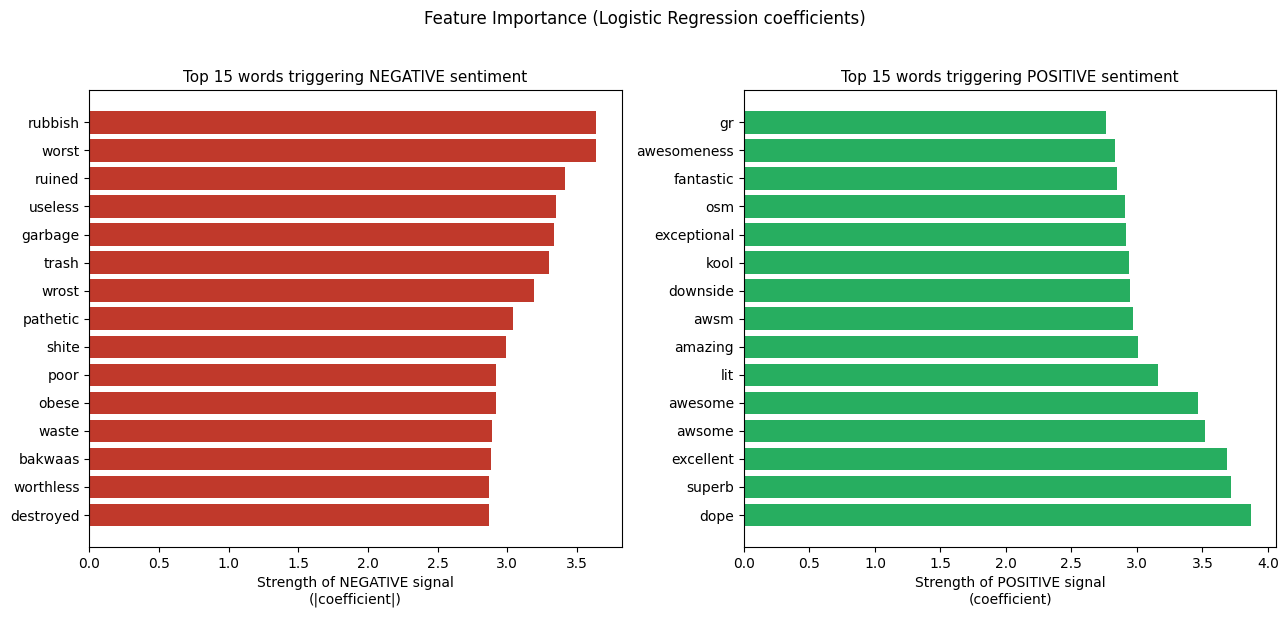


Top 10 NEGATIVE trigger words:
  rubbish                    coef = -3.639
  worst                      coef = -3.634
  ruined                     coef = -3.413
  useless                    coef = -3.347
  garbage                    coef = -3.336
  trash                      coef = -3.297
  wrost                      coef = -3.192
  pathetic                   coef = -3.038
  shite                      coef = -2.990
  poor                       coef = -2.920

Top 10 POSITIVE trigger words:
  dope                       coef = +3.870
  superb                     coef = +3.719
  excellent                  coef = +3.689
  awsome                     coef = +3.517
  awesome                    coef = +3.466
  lit                        coef = +3.165
  amazing                    coef = +3.007
  awsm                       coef = +2.968
  downside                   coef = +2.950
  kool                       coef = +2.937

Per-app performance (Logistic Regression on test set)
   App  N (test)  Acc

In [3]:
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, confusion_matrix,
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42


# Load data (Colab upload widget; falls back to local path)
DATA_PATH = "DatingAppReviewsDataset.csv"

try:
    from google.colab import files  # type: ignore
    if not os.path.exists(DATA_PATH):
        print("Upload DatingAppReviewsDataset.csv:")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
except ImportError:
    pass


# Stage 1: Load and label
print("STAGE 1: Loading & labeling")

df = pd.read_csv(DATA_PATH)
print(f"Raw rows: {len(df):,}")

df = df.dropna(subset=["Review"])
df = df[df["Rating"].between(1, 5)]
# Binary: 1-2 -> Negative (0), 4-5 -> Positive (1), drop 3-star neutrals
df = df[df["Rating"] != 3].copy()
df["label"] = (df["Rating"] >= 4).astype(int)
df["Review"] = df["Review"].astype(str)

print(f"After dropping nulls + neutrals: {len(df):,}")
print(f"Class balance -> Neg: {(df['label']==0).sum():,}  Pos: {(df['label']==1).sum():,}")
print(f"Apps: {dict(df['App'].value_counts())}")


# Stage 2: Text preprocessing
print("\nSTAGE 2: Text preprocessing")

_punct_re = re.compile(r"[^a-z\s]")

def clean_text(s: str) -> str:
    s = s.lower()
    s = _punct_re.sub(" ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

t0 = time.time()
df["clean"] = df["Review"].map(clean_text)
df = df[df["clean"].str.len() > 0]
print(f"Cleaned in {time.time()-t0:.1f}s. Final rows: {len(df):,}")


# Stage 3: Vectorize with bag-of-words
print("\nSTAGE 3: CountVectorizer (Bag-of-Words)")

vectorizer = CountVectorizer(
    stop_words=list(ENGLISH_STOP_WORDS),
    min_df=5,
    max_features=20000,
    ngram_range=(1, 1),
)
t0 = time.time()
X_full = vectorizer.fit_transform(df["clean"])
y = df["label"].values
print(f"Vectorized in {time.time()-t0:.1f}s")
print(f"Feature matrix: {X_full.shape}  (sparse, {X_full.nnz:,} non-zeros)")


# Stage 4: Chi-square feature selection (replaces PCA per reviewer feedback)
print("\nSTAGE 4: Chi-square feature selection")

K = 3000
selector = SelectKBest(chi2, k=K)
t0 = time.time()
X = selector.fit_transform(X_full, y)
print(f"Selected top {K} features in {time.time()-t0:.1f}s")
print(f"Reduced feature matrix: {X.shape}")

all_features = np.array(vectorizer.get_feature_names_out())
kept_features = all_features[selector.get_support()]


# Stage 5: 80/20 stratified train/test split
print("\nSTAGE 5: 80/20 stratified split")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}")


# Stage 6: Train and evaluate the three models
print("\nSTAGE 6: Training the three models")

models = {
    "Logistic Regression": LogisticRegression(
        penalty="l2", C=1.0, max_iter=1000, solver="liblinear",
        random_state=RANDOM_STATE,
    ),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=25, min_samples_leaf=50, random_state=RANDOM_STATE,
    ),
}

results = {}
for name, model in models.items():
    print(f"\n{name}")
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)

    results[name] = dict(
        model=model, preds=preds, accuracy=acc, f1=f1,
        precision=prec, recall=rec, confusion_matrix=cm, train_time=train_time,
    )
    print(f"  Train: {train_time:.1f}s  |  Acc={acc:.4f}  F1={f1:.4f}  "
          f"Prec={prec:.4f}  Rec={rec:.4f}")


# Results summary table
print("\nFINAL COMPARISON")

summary = pd.DataFrame({
    name: {
        "Accuracy": r["accuracy"], "F1-Score": r["f1"],
        "Precision": r["precision"], "Recall": r["recall"],
        "Train time (s)": r["train_time"],
    }
    for name, r in results.items()
}).T.round(4)
print(summary.to_string())
summary.to_csv("model_comparison.csv")

best = max(results, key=lambda k: results[k]["f1"])
print(f"\nWinner by F1: {best}")


# Plot: confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, r) in zip(axes, results.items()):
    cm = r["confusion_matrix"]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name}\nF1={r['f1']:.3f}", fontsize=11)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Neg", "Pos"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Neg", "Pos"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color=color, fontsize=11)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=140, bbox_inches="tight")
plt.show()


# Feature importance: top trigger words from Logistic Regression coefficients
lr = results["Logistic Regression"]["model"]
coefs = lr.coef_[0]

neg_idx = np.argsort(coefs)[:15]
neg_words = kept_features[neg_idx]
neg_coefs = coefs[neg_idx]

pos_idx = np.argsort(coefs)[-15:]
pos_words = kept_features[pos_idx]
pos_coefs = coefs[pos_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].barh(range(len(neg_words)), -neg_coefs, color="#c0392b")
axes[0].set_yticks(range(len(neg_words))); axes[0].set_yticklabels(neg_words)
axes[0].invert_yaxis()
axes[0].set_xlabel("Strength of NEGATIVE signal\n(|coefficient|)")
axes[0].set_title("Top 15 words triggering NEGATIVE sentiment", fontsize=11)

axes[1].barh(range(len(pos_words)), pos_coefs, color="#27ae60")
axes[1].set_yticks(range(len(pos_words))); axes[1].set_yticklabels(pos_words)
axes[1].invert_yaxis()
axes[1].set_xlabel("Strength of POSITIVE signal\n(coefficient)")
axes[1].set_title("Top 15 words triggering POSITIVE sentiment", fontsize=11)

plt.suptitle("Feature Importance (Logistic Regression coefficients)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=140, bbox_inches="tight")
plt.show()

print("\nTop 10 NEGATIVE trigger words:")
for w, c in zip(neg_words[:10], neg_coefs[:10]):
    print(f"  {w:25s}  coef = {c:+.3f}")

print("\nTop 10 POSITIVE trigger words:")
for w, c in zip(pos_words[-10:][::-1], pos_coefs[-10:][::-1]):
    print(f"  {w:25s}  coef = {c:+.3f}")


# Per-app performance slice
print("\nPer-app performance (Logistic Regression on test set)")

_, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
test_apps = df.iloc[test_idx]["App"].values
preds_lr = results["Logistic Regression"]["preds"]

per_app = []
for app in ["Tinder", "Bumble", "Hinge"]:
    mask = test_apps == app
    if mask.sum() == 0: continue
    per_app.append({
        "App": app, "N (test)": int(mask.sum()),
        "Accuracy": round(accuracy_score(y_test[mask], preds_lr[mask]), 4),
        "F1": round(f1_score(y_test[mask], preds_lr[mask]), 4),
    })
per_app_df = pd.DataFrame(per_app)
print(per_app_df.to_string(index=False))
per_app_df.to_csv("per_app_performance.csv", index=False)

print("\nDONE  —  outputs saved: model_comparison.csv, per_app_performance.csv,")
print("                       confusion_matrices.png, feature_importance.png")